# try model LSTM for 1h, 1d, fear and greed

# Import Libraries



In [10]:
import tensorflow as tf
# سطر للتأكد من أن الكارت مرئي فعلاً
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

Still not working. Check PATH or CUDA version.


In [11]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Load Data

In [12]:
df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_fng = pd.read_csv("data/Fear_Greed_Daily.csv")



In [13]:
for df in [df_hourly, df_daily, df_fng]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.sort_values('datetime', inplace=True)

In [14]:
df = pd.merge_asof(df_hourly, df_daily[['datetime', 'close']], on='datetime', direction='backward', suffixes=('', '_daily'))
df = pd.merge_asof(df, df_fng, on='datetime', direction='backward')

In [15]:
print("Data Loaded Successfully. Shape:", df.shape)

Data Loaded Successfully. Shape: (74836, 8)


In [16]:
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.sort_index(inplace=True)

Missing values before cleaning:
datetime               0
open                   0
high                   0
low                    0
close                  0
volume                 0
close_daily            0
Fear_Greed_Index    4021
dtype: int64


In [17]:
df.dropna(inplace=True)
print(f"Missing values after cleaning:\n{df.isnull().sum()}")

Missing values after cleaning:
datetime            0
open                0
high                0
low                 0
close               0
volume              0
close_daily         0
Fear_Greed_Index    0
dtype: int64


# Data Exploration (EDA)


In [18]:
df.head()


,datetime,open,high,low,close,volume,close_daily,Fear_Greed_Index
4021,2018-02-01 00:00:00,10285.10,10335.00,10215.07,10263.18,594.441290,9170.540039,30.0
4022,2018-02-01 01:00:00,10263.18,10328.98,10216.00,10247.49,591.515725,9170.540039,30.0
4023,2018-02-01 02:00:00,10249.43,10317.73,10176.89,10199.61,479.412562,9170.540039,30.0
4024,2018-02-01 03:00:00,10199.61,10250.79,9959.04,10069.80,739.435309,9170.540039,30.0
4025,2018-02-01 04:00:00,10069.77,10256.00,10000.01,10245.79,649.939854,9170.540039,30.0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70815 entries, 4021 to 74835
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          70815 non-null  datetime64[us]
 1   open              70815 non-null  float64       
 2   high              70815 non-null  float64       
 3   low               70815 non-null  float64       
 4   close             70815 non-null  float64       
 5   volume            70815 non-null  float64       
 6   close_daily       70815 non-null  float64       
 7   Fear_Greed_Index  70815 non-null  float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 4.3 MB


In [20]:
df.describe()


,datetime,open,high,low,close,volume,close_daily,Fear_Greed_Index
count,70815,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000
mean,2022-02-19 13:56:51.192544,38458.283241,38611.659134,38297.279907,38459.107776,2701.007947,38489.053513,46.567394
min,2018-02-01 00:00:00,3172.620000,3184.750000,3156.260000,3172.050000,0.000000,3236.761719,5.000000
25%,2020-02-12 09:30:00,9500.570000,9538.875000,9452.520000,9500.015000,827.999391,9525.750977,27.000000
50%,2022-02-20 07:00:00,28503.710000,28605.150000,28376.110000,28504.360000,1474.187870,28454.978516,46.000000
75%,2024-02-27 23:30:00,59583.940000,59845.050000,59318.965000,59584.500000,2841.440770,59498.792969,65.000000
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,124752.531250,95.000000
std,NaN,32559.031168,32659.219432,32455.052930,32559.063283,3960.594331,32554.496524,21.899006


# Feature Engineering

In [21]:
print("Engineering 15 Professional Features")

Engineering 15 Professional Features


### EMA

In [22]:
df['EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['close'].ewm(span=50, adjust=False).mean()

## Momentum Indicators

### 1. RSI (14)

In [23]:
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

### 2. MACD (12, 26, 9)

In [24]:
exp12 = df['close'].ewm(span=12, adjust=False).mean()
exp26 = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp12 - exp26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

### 3. Stochastic %K (14)

In [25]:
low_14 = df['low'].rolling(window=14).min()
high_14 = df['high'].rolling(window=14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14))
df['Will_R'] = -100 * ((high_14 - df['close']) / (high_14 - low_14))

##  Volatility Indicators

### 1. ATR (Average True Range)

In [26]:
high_low = df['high'] - df['low']
high_pc = np.abs(df['high'] - df['close'].shift())
low_pc = np.abs(df['low'] - df['close'].shift())
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df['ATR'] = tr.rolling(window=14).mean()

### 2. Bollinger Bands (20, 2) & BB Width

In [27]:
ma20 = df['close'].rolling(window=20).mean()
std20 = df['close'].rolling(window=20).std()
df['BB_Width'] = (std20 * 4) / ma20

## Cycles & Strength 

### 1. CCI (20)

In [28]:
tp = (df['high'] + df['low'] + df['close']) / 3
ma_tp = tp.rolling(window=20).mean()
mad_tp = tp.rolling(window=20).apply(lambda x: np.abs(x - x.mean()).mean())
df['CCI'] = (tp - ma_tp) / (0.015 * mad_tp)

## Returns

In [29]:
cols_to_pct = ['open', 'high', 'low', 'close', 'volume', 'EMA_10', 'EMA_20', 'EMA_50', 'ATR']
for col in cols_to_pct:
    df[col + '_ret'] = df[col].pct_change()

## Target

In [30]:
df['Target'] = (df['close'].shift(-24) > df['close']).astype(int)

In [31]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

### test

In [32]:
df.describe()


,datetime,open,high,low,close,volume,close_daily,Fear_Greed_Index,EMA_10,EMA_20,...,open_ret,high_ret,low_ret,close_ret,volume_ret,EMA_10_ret,EMA_20_ret,EMA_50_ret,ATR_ret,Target
count,70793,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,...,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000,70793.000000
mean,2022-02-19 23:48:07.454974,38466.468657,38619.860400,38305.457221,38467.309012,2701.340901,38497.374567,46.571257,38463.468237,38459.154315,...,0.000053,0.000049,0.000056,0.000053,0.152411,0.000031,0.000029,0.000028,0.002279,0.518342
min,2018-02-01 19:00:00,3172.620000,3184.750000,3156.260000,3172.050000,0.000000,3236.761719,5.000000,3192.089210,3208.311460,...,-0.182201,-0.129828,-0.243869,-0.182115,-1.000000,-0.047895,-0.030895,-0.015680,-0.450443,0.000000
25%,2020-02-13 00:00:00,9500.970000,9538.920000,9453.850000,9500.780000,828.045180,9525.750977,27.000000,9498.118887,9505.222472,...,-0.002380,-0.002188,-0.002004,-0.002382,-0.270306,-0.000713,-0.000538,-0.000378,-0.030053,0.000000
50%,2022-02-20 17:00:00,28509.580000,28623.630000,28386.510000,28510.000000,1474.318520,28478.484375,46.000000,28496.166005,28459.298473,...,0.000068,-0.000215,0.000339,0.000067,-0.034660,0.000051,0.000040,0.000031,-0.000409,1.000000
75%,2024-02-28 05:00:00,59592.710000,59851.100000,59339.830000,59594.030000,2842.133699,59504.132812,65.000000,59625.647408,59629.815412,...,0.002532,0.001990,0.002532,0.002540,0.310859,0.000814,0.000628,0.000464,0.028739,1.000000
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,124752.531250,95.000000,125062.361818,124694.100415,...,0.173670,0.152525,0.271352,0.173840,155.308443,0.031305,0.020696,0.010494,1.701271,1.000000
std,NaN,32560.467544,32660.664463,32456.468177,32560.485618,3961.043173,32555.763990,21.899840,32557.478385,32554.411271,...,0.007039,0.006437,0.007325,0.007039,0.984398,0.002152,0.001521,0.000961,0.069367,0.499667


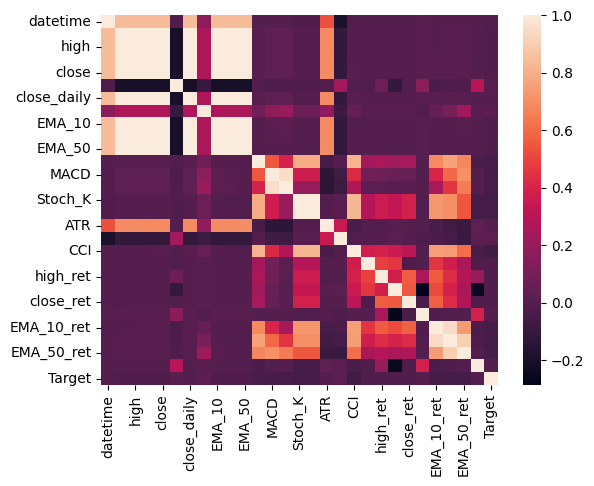

In [33]:
sns.heatmap(df.corr())
plt.show()
# !pip install seaborn

## remove the bad column  

In [34]:
df = df.drop("open", axis=1)
df = df.drop("low", axis=1)
df = df.drop("high", axis=1)
df = df.drop("close", axis=1)
# df = df.drop("BB_Upper", axis=1)
df = df.drop("EMA_50", axis=1)
df = df.drop("EMA_10", axis=1)
df = df.drop("EMA_20", axis=1)


In [35]:
df = df.drop(["BB_Lower", "ATR"], axis=1, errors='ignore')

final_features = [
    'close_ret', 'volume_ret', 'open_ret', 'ATR_ret', 'EMA_10_ret',
    'RSI', 'MACD', 'MACD_Signal', 'Stoch_K', 'Will_R',
    'BB_Width', 'CCI', 'high_ret' 
]

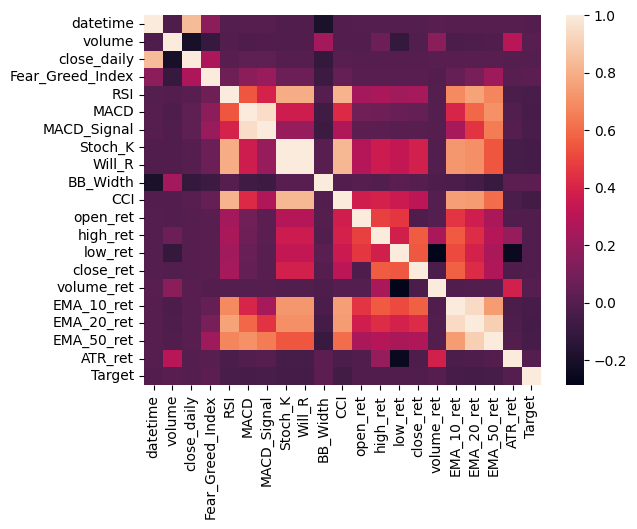

In [36]:
sns.heatmap(df.corr())
plt.show()

# Data Scaling

In [37]:
X_data = df[final_features].values
y_data = df['Target'].values

In [38]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)

In [39]:
joblib.dump(scaler, "egx360_scaler.pkl")
print("Data Scaled and Scaler saved.")

Data Scaled and Scaler saved.


# Train / Test Split

In [40]:
split_idx = int(len(X_scaled) * 0.8)

In [41]:
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

In [42]:
print(f"📅 Training records: {len(train_data)} | Testing records: {len(test_data)}")

📅 Training records: 56634 | Testing records: 14159


# Create Sequences

In [43]:
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72

In [44]:
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train shape: {X_train.shape}") # (Samples, Time Steps, Features)


📦 X_train shape: (56562, 72, 13)


# Build Model

In [45]:
def build_v1_pure(input_shape):
    inputs = Input(shape=input_shape)
    
    # طبقتين Bi-LSTM لفهم تسلسل الوقت
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.2)(x)
    
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

In [46]:
model = build_v1_pure((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train Model

In [47]:
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

In [48]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_V1_Baseline.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

In [49]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 138s 75ms/step - accuracy: 0.5154 - loss: 0.6930 - val_accuracy: 0.4976 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 2/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 125s 66ms/step - accuracy: 0.5250 - loss: 0.6919 - val_accuracy: 0.5029 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 3/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 118s 67ms/step - accuracy: 0.5302 - loss: 0.6910 - val_accuracy: 0.5139 - val_loss: 0.6960 - learning_rate: 0.0010
Epoch 4/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 118s 67ms/step - accuracy: 0.5270 - loss: 0.6903 - val_accuracy: 0.5093 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 5/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 121s 68ms/step - accuracy: 0.5302 - loss: 0.6898 - val_accuracy: 0.5113 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 6/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 108s 61ms/step - accuracy: 0.5298 - loss: 0.6892 - val_accuracy: 0.5122 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 7/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 111s 63ms

# Evaluate Model

In [50]:
y_probs = model.predict(X_test)
final_preds = (y_probs > 0.50).astype(int)

441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


In [51]:
print("\n Final Classification Report (Baseline V1):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))


 Final Classification Report (Baseline V1):
              precision    recall  f1-score   support

        Down       0.50      0.56      0.53      6904
          Up       0.52      0.46      0.49      7183

    accuracy                           0.51     14087
   macro avg       0.51      0.51      0.51     14087
weighted avg       0.51      0.51      0.51     14087



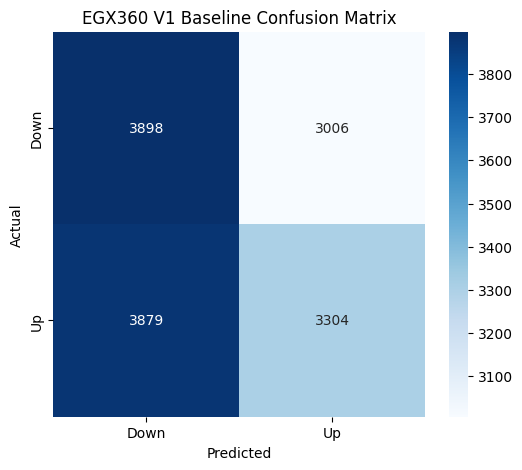

In [52]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title("EGX360 V1 Baseline Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()